<a href="https://colab.research.google.com/github/LikithaTummapudi/Quantum-Teleportation-Simulator/blob/main/teleportation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q qiskit
!pip install -q qiskit_aer
!pip install -q qiskit qiskit_experiments
!pip install -q qiskit-ibm-runtime
!pip install -q pylatexenc

In [2]:
!pip show qiskit

Name: qiskit
Version: 2.4.0
Summary: An open-source SDK for working with quantum computers at the level of extended quantum circuits, operators, and primitives.
Home-page: https://www.ibm.com/quantum/qiskit
Author: 
Author-email: Qiskit Development Team <qiskit@us.ibm.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: dill, numpy, rustworkx, scipy, stevedore, typing-extensions
Required-by: ibm-quantum-schemas, qiskit-aer, qiskit-experiments, qiskit-ibm-experiment, qiskit-ibm-runtime, samplomatic


In [3]:
from qiskit import QuantumCircuit
import numpy as np

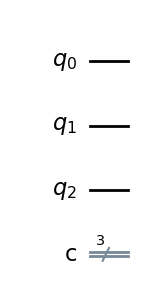

In [4]:
#creating 3-qubit circuit
qc=QuantumCircuit(3,3)
qc.draw(output="mpl")

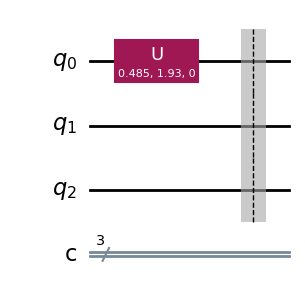

In [5]:
#creating unkown quantum state using u gate.(Alice is having this)
theta = np.random.uniform(0.0, 1.0) * np.pi  # from 0 to pi
varphi = np.random.uniform(0.0, 2.0) * np.pi  # from 0 to 2*pi

qc.u(theta,varphi,0.0,0)
qc.barrier()
qc.draw(output="mpl")

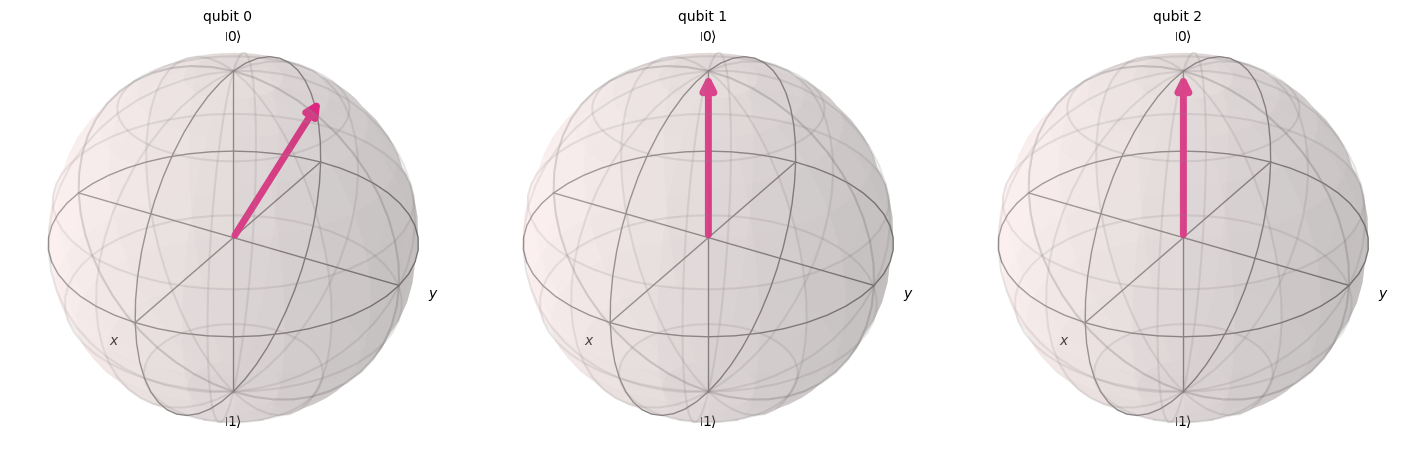

In [6]:
#bloch sphere
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
out_vector=Statevector(qc)
plot_bloch_multivector(out_vector)

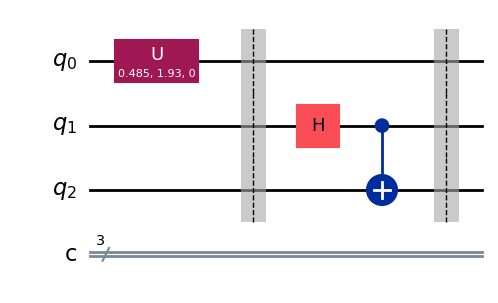

In [7]:
qc.h(1)   # Alice and Bob are together in the same place and set up an entangled pair.
qc.cx(1,2)
qc.barrier()   # Consider that Alice and Bob might move their qubits to different physical locations, now.
qc.draw(output="mpl")


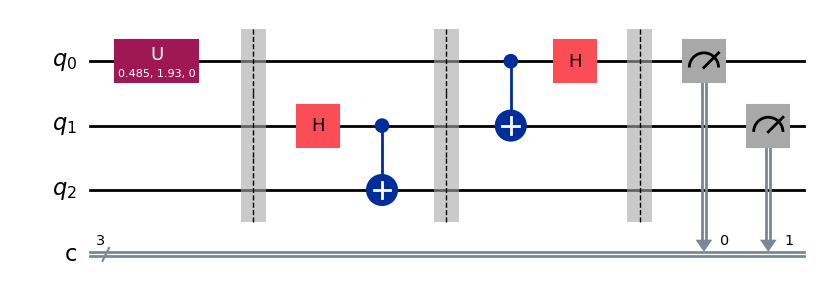

In [8]:
# Alice entangles the unknown state with her part of the e-bit, using the CNOT gate and H gate.
qc.cx(0,1)
qc.h(0)
qc.barrier()
qc.measure(0,0)
qc.measure(1,1)
qc.draw(output="mpl")


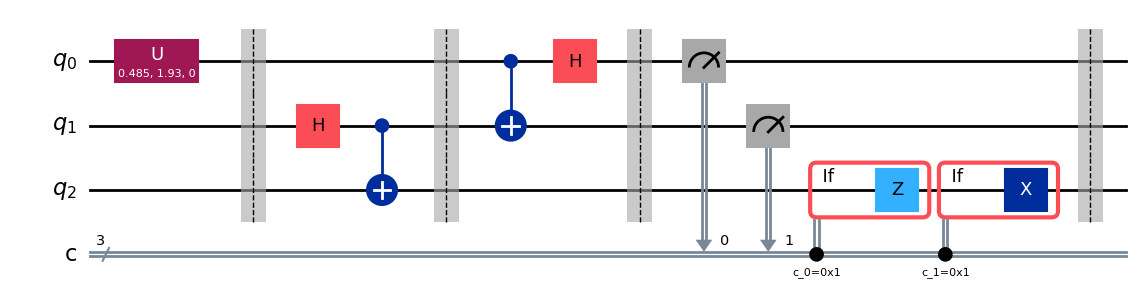

In [9]:
#Alice has sent the results to Bob. Bob performs corrections.

with qc.if_test((0,1)):  #If measurement of qubit 0 = 1 → apply Z
  qc.z(2)
with qc.if_test((1,1)):  #If measurement of qubit 1 = 1 → apply X
  qc.x(2)
qc.barrier()
qc.draw(output="mpl")

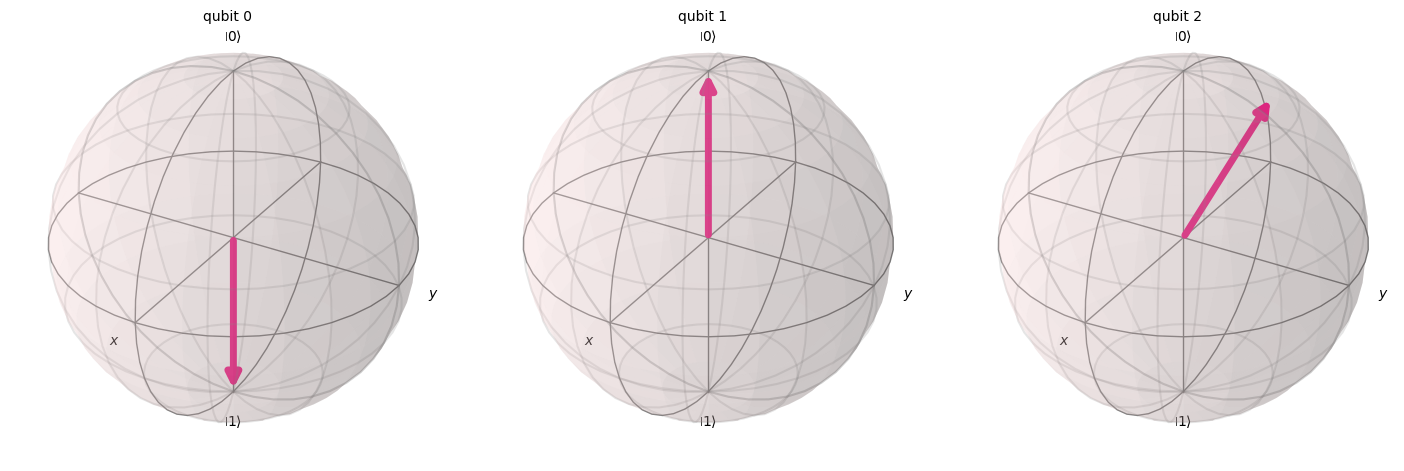

In [10]:
from qiskit_aer import StatevectorSimulator
backened=StatevectorSimulator()
vector=backened.run(qc, shots=1).result().get_statevector()
plot_bloch_multivector(vector)

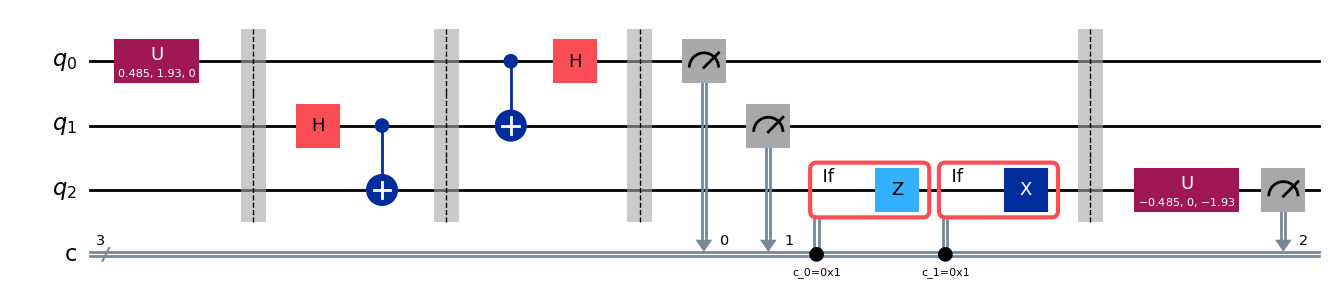

In [11]:
# Validating teleportation by reversing
# Apply the inverse of u gate to measure |0>

qc.u(theta,varphi,0.0,2).inverse()
qc.measure(2,2)   #add measurement gate
qc.draw(output="mpl")
